# A Simple Variational Autoencoder (VAE) on MNIST with PyTorch

This notebook implements a small Variational Autoencoder (VAE) trained on the
MNIST handwritten digits dataset.

The goal is to:

1. Understand the pieces that make up a VAE:
   - Encoder network
   - Latent space (mean and log-variance)
   - Reparameterization trick
   - Decoder network
   - VAE loss (reconstruction + KL divergence)
2. See how to implement each piece step by step in PyTorch.


In [57]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import numpy as np

# Use GPU if available, otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Hyperparameters
batch_size = 128
learning_rate = 1e-3
num_epochs = 10

# MNIST image dimensions
image_size = 28 * 28  # we will flatten 28x28 images into 784-dimensional vectors
latent_dim = 2        # dimensionality of the latent space (2 for easy visualization)
hidden_dim = 400      # size of hidden layer in encoder/decoder

Using device: cpu


## 2. Loading the MNIST Dataset

We will:

- Download the MNIST dataset using `torchvision.datasets.MNIST`
- Apply a basic transform to convert images to tensors and scale them to [0, 1]
- Create training and test data loaders

In [58]:
# Transform: convert PIL images to tensors and scale pixel values to [0, 1]
transform = transforms.ToTensor()

# Download and create training dataset
train_dataset = datasets.MNIST(
    root="data",
    train=True,
    transform=transform,
    download=True,
)

# Download and create test dataset
test_dataset = datasets.MNIST(
    root="data",
    train=False,
    transform=transform,
    download=True,
)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("Number of training batches:", len(train_loader))
print("Number of test batches:", len(test_loader))

Number of training batches: 469
Number of test batches: 79


## 3. Visualizing a Few MNIST Images

Before building the VAE, it is useful to look at the data.

In this cell, we:

- Get a batch of images from the training loader
- Plot the first few images

Batch shape: torch.Size([128, 1, 28, 28])


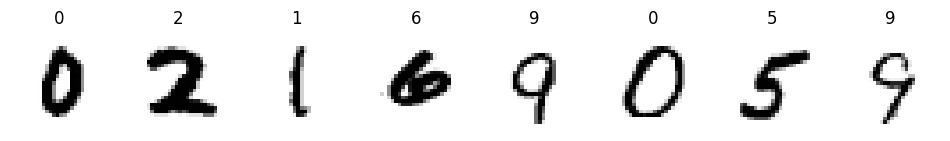

In [59]:
# %%
# Get one batch of images and labels
images, labels = next(iter(train_loader))

print("Batch shape:", images.shape)  # (batch_size, 1, 28, 28)

# Plot the first 8 images in the batch
fig, axes = plt.subplots(1, 8, figsize=(12, 2))
for i in range(8):
    axes[i].imshow(images[i].squeeze(0), cmap="grey_r")
    axes[i].set_title(int(labels[i]))
    axes[i].axis("off")
plt.show()


## 4. The Encoder Network

The encoder takes an input image and maps it to a latent distribution.
For a VAE, we want to output:

- A mean vector μ (mu) of size `latent_dim`
- A log-variance vector log σ² (log_var) of size `latent_dim`

We will:

- Flatten the input image (from shape `(batch, 1, 28, 28)` to `(batch, 784)`)
- Pass it through a fully connected hidden layer with ReLU activation
- Use two separate linear layers to produce `mu` and `log_var`

In [60]:
class Encoder(nn.Module): 
    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super(Encoder, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc_mu = nn.Linear(hidden_dim, latent_dim)
        self.fc_log_var = nn.Linear(hidden_dim, latent_dim)  # renamed for clarity

    def forward(self, x): 
        h = F.relu(self.fc1(x))
        mu = self.fc_mu(h)
        log_var = self.fc_log_var(h)
        return mu, log_var

In [61]:
enc = Encoder(784, 400, 2)
X = torch.randn(16, 1, 28, 28)
mu, log_var = enc(X.view(-1, 784))

## 5. The Reparameterization Trick

The VAE needs to sample from a Gaussian distribution with mean μ and variance σ².
However, we want this sampling operation to be differentiable so that gradients can flow through the network.

The reparameterization trick:

- Sample ε ∼ N(0, I)
- Compute z = μ + σ * ε, where σ = exp(0.5 * log_var)

This is implemented as a small helper function.

In [62]:
def reparameterize(mu: torch.Tensor, log_var: torch.Tensor) -> torch.Tensor:
    """
    Perform the reparameterization trick:
    z = mu + sigma * epsilon, where epsilon ~ N(0, I).

    mu: tensor of shape (batch_size, latent_dim)
    log_var: tensor of shape (batch_size, latent_dim)
    returns: z of shape (batch_size, latent_dim)
    """
    std = torch.exp(0.5 * log_var)  # sigma = exp(1/2 * log_var)
    eps = torch.randn_like(std)     # random noise with same shape as std
    z = mu + std * eps
    return z

## 6. The Decoder Network

The decoder takes a latent vector `z` and tries to reconstruct the original image.

Steps:

- Input: latent vector of size `latent_dim`
- Fully connected hidden layer with ReLU
- Output layer that maps back to `image_size` (784)
- Apply a sigmoid so outputs are in [0, 1], matching pixel intensities

In [63]:
class Decoder(nn.Module):
    def __init__(self, latent_dim: int, hidden_dim: int, output_dim: int):
        super(Decoder, self).__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.fc_out = nn.Linear(hidden_dim, output_dim)
    
    def forward(self, z): 
        h = F.relu(self.fc1(z))
        x_recon = self.fc_out(h)
        x_recon = torch.sigmoid(x_recon)  # Ensure output is in [0, 1]
        return x_recon

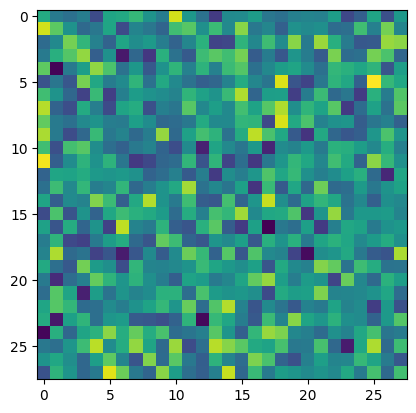

In [64]:
dec = Decoder(latent_dim=2, hidden_dim=400, output_dim=784)
X_hat = dec(mu).view(16, 1, 28, 28)
plt.imshow(X_hat[0,0].detach().numpy())

## 7. Putting It Together: The VAE Module

The VAE class combines:

- An encoder that produces `mu` and `log_var`
- A reparameterization step to get `z`
- A decoder that reconstructs the image from `z`

The `forward` method returns:

- `x_recon`: reconstructed images
- `mu` and `log_var`: useful for computing the KL divergence term in the loss

In [65]:
# class VAE(nn.Module):
#     def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
#         super(VAE, self).__init__()
#         self.encoder = Encoder(input_dim, hidden_dim, latent_dim) # maps to mean, var
#         self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

#     def forward(self, x):
#         # x has shape (batch, channels, x, y)
#         # reshape to (batch, channels * x * y) = (batch, 784)
#         x_flat = x.view(x.size(0), -1)
#         mu, log_sigma = self.encoder(x_flat) # mu and sigma have shape (batch, latent_dim)

#         # z = random_normal(mean=mu, sigma=exp(log_sigma))
#         # z = standard_normal * sigma + mu

#         sigma = torch.exp(log_sigma)
#         z = torch.randn_like(sigma) * sigma + mu

#         # z = reparameterize(mu, log_sigma)
#         x_recon = self.decoder(z)
#         return x_recon 
#         # return x_recon, mu, log_sigma

In [66]:
class VAE(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, latent_dim: int):
        super(VAE, self).__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

    def forward(self, x):
        # x: (batch, 1, 28, 28) -> flatten to (batch, 784)
        x_flat = x.view(x.size(0), -1)
        mu, log_var = self.encoder(x_flat)
        # reparameterize: z = mu + std * eps, std = exp(0.5 * log_var)
        z = reparameterize(mu, log_var)
        x_recon = self.decoder(z)
        return x_recon, mu, log_var

In [ ]:
# vae = VAE(input_dim=784, hidden_dim=400, latent_dim=2)
# X_hat = vae(X.view(-1, 784))
# X_hat = X_hat.detach().numpy()  
# plt.imshow(X_hat[0].reshape(28, 28)) # changes; randomization makes different output each time

AttributeError: 'tuple' object has no attribute 'detach'

## 8. VAE Loss Function: Reconstruction + KL Divergence

The VAE loss has two parts:

1. **Reconstruction loss**: measures how close the reconstructed images are to the original images.
   - We will use Binary Cross-Entropy (BCE) between the original and reconstructed pixel values.
2. **KL divergence** between the approximate posterior `q(z|x)` and the prior `p(z) = N(0, I)`.
   - For each dimension of z, if q(z|x) = N(μ, σ²) and p(z) = N(0, 1), the KL divergence is:
     \[
     \text{KL} = -\frac{1}{2} \sum_{j=1}^d (1 + \log \sigma_j^2 - \mu_j^2 - \sigma_j^2)
     \]
   - We can compute this directly from `mu` and `log_var`.

The total loss is:

\[
\mathcal{L} = \text{ReconstructionLoss} + \text{KL}
\]

In [68]:
def loss_function(x: torch.Tensor, x_recon: torch.Tensor, mu: torch.Tensor, log_var: torch.Tensor):
    """
    Compute the VAE loss for a batch.

    x: original images, shape (batch_size, 1, 28, 28)
    x_recon: reconstructed images, shape (batch_size, 784)
    mu: means of q(z|x), shape (batch_size, latent_dim)
    log_var: log-variances of q(z|x), shape (batch_size, latent_dim)
    """
    batch_size = x.size(0)

    # Flatten original images to match reconstruction shape
    x_flat = x.view(batch_size, -1)

    # Reconstruction loss (sum over pixels, average over batch)
    # We use reduction='sum' then divide by batch size for a mean-like quantity
    recon_loss = F.binary_cross_entropy(
        x_recon,
        x_flat,
        reduction="sum",
    ) / batch_size

    # KL divergence between q(z|x) and p(z) = N(0, I)
    # For each element: -0.5 * (1 + log_var - mu^2 - exp(log_var))
    kl_div = -0.5 * torch.sum(1 + log_var - mu.pow(2) - torch.exp(log_var))
    kl_div = kl_div / batch_size

    # Total VAE loss
    loss = recon_loss + kl_div
    return loss, recon_loss, kl_div

## 9. Creating the Model and Optimizer

We now:

- Create an instance of the `VAE` model
- Move it to the device (CPU or GPU)
- Create an Adam optimizer

In [69]:
vae = VAE(input_dim=image_size, hidden_dim=hidden_dim, latent_dim=latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=learning_rate)

print(vae)

VAE(
  (encoder): Encoder(
    (fc1): Linear(in_features=784, out_features=400, bias=True)
    (fc_mu): Linear(in_features=400, out_features=2, bias=True)
    (fc_log_var): Linear(in_features=400, out_features=2, bias=True)
  )
  (decoder): Decoder(
    (fc1): Linear(in_features=2, out_features=400, bias=True)
    (fc_out): Linear(in_features=400, out_features=784, bias=True)
  )
)


## 10. Training Loop

In this cell, we write the training loop.

For each epoch:

- Loop over batches from the training data
- Move the batch to the device
- Compute the VAE outputs and loss
- Backpropagate and update parameters
- Track average loss per epoch

We also evaluate the loss on the test set to see how the model generalizes.


In [71]:
def train_epoch(model, data_loader, optimizer, device):
    model.train()
    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0

    for x, _ in data_loader:
        x = x.to(device)

        optimizer.zero_grad()
        x_recon, mu, log_var = model(x)
        loss, recon_loss, kl_div = loss_function(x, x_recon, mu, log_var)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_recon += recon_loss.item()
        running_kl += kl_div.item()

    num_batches = len(data_loader)
    return (
        running_loss / num_batches,
        running_recon / num_batches,
        running_kl / num_batches,
    )


def eval_epoch(model, data_loader, device):
    model.eval()
    running_loss = 0.0
    running_recon = 0.0
    running_kl = 0.0

    with torch.no_grad():
        for x, _ in data_loader:
            x = x.to(device)
            x_recon, mu, log_var = model(x)
            loss, recon_loss, kl_div = loss_function(x, x_recon, mu, log_var)

            running_loss += loss.item()
            running_recon += recon_loss.item()
            running_kl += kl_div.item()

    num_batches = len(data_loader)
    return (
        running_loss / num_batches,
        running_recon / num_batches,
        running_kl / num_batches,
    )

## 11. Running the Training

Now we actually train the VAE for a number of epochs.
We will store the losses for plotting later.

In [74]:
train_losses = []
train_recon_losses = []
train_kl_losses = []

test_losses = []
test_recon_losses = []
test_kl_losses = []

num_epochs = 5

for epoch in range(1, num_epochs + 1):
    train_loss, train_recon, train_kl = train_epoch(vae, train_loader, optimizer, device)
    test_loss, test_recon, test_kl = eval_epoch(vae, test_loader, device)

    train_losses.append(train_loss)
    train_recon_losses.append(train_recon)
    train_kl_losses.append(train_kl)

    test_losses.append(test_loss)
    test_recon_losses.append(test_recon)
    test_kl_losses.append(test_kl)

    print(
        f"Epoch {epoch:02d} | "
        f"Train Loss: {train_loss:.4f} (Recon: {train_recon:.4f}, KL: {train_kl:.4f}) | "
        f"Test Loss: {test_loss:.4f} (Recon: {test_recon:.4f}, KL: {test_kl:.4f})"
    )

Epoch 01 | Train Loss: 156.2965 (Recon: 150.7327, KL: 5.5637) | Test Loss: 155.4434 (Recon: 149.9801, KL: 5.4633)
Epoch 02 | Train Loss: 155.3680 (Recon: 149.7561, KL: 5.6119) | Test Loss: 154.6810 (Recon: 149.0341, KL: 5.6469)
Epoch 03 | Train Loss: 154.5681 (Recon: 148.9313, KL: 5.6368) | Test Loss: 154.4633 (Recon: 148.6915, KL: 5.7718)
Epoch 04 | Train Loss: 153.8925 (Recon: 148.2040, KL: 5.6886) | Test Loss: 153.3333 (Recon: 147.7396, KL: 5.5937)
Epoch 05 | Train Loss: 153.3024 (Recon: 147.5874, KL: 5.7150) | Test Loss: 152.9231 (Recon: 147.3177, KL: 5.6055)


## 12. Plotting the Training and Test Losses

We can now plot how the total loss, reconstruction loss, and KL loss behave over epochs.

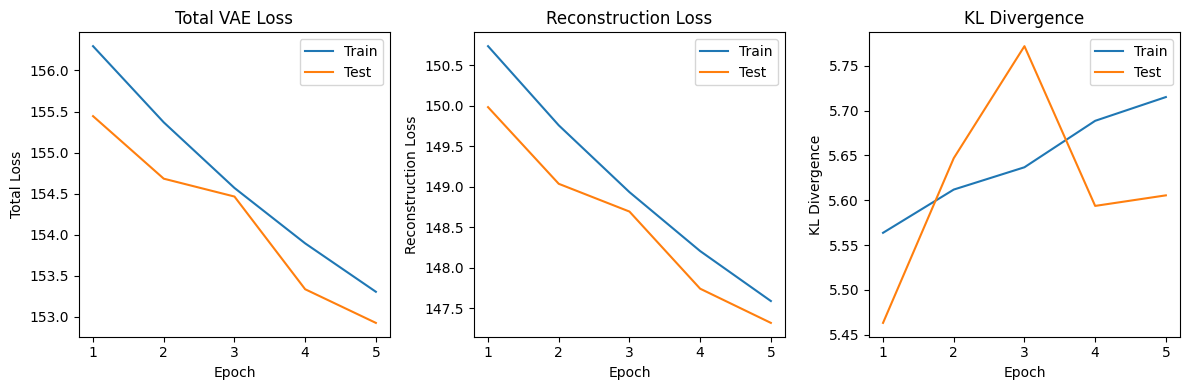

In [ ]:
epochs = np.arange(1, num_epochs + 1)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.plot(epochs, train_losses, label="Train")
plt.plot(epochs, test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Total Loss")
plt.title("Total VAE Loss")
plt.legend()

plt.subplot(1, 3, 2)
plt.plot(epochs, train_recon_losses, label="Train")
plt.plot(epochs, test_recon_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Reconstruction Loss")
plt.title("Reconstruction Loss")
plt.legend()

plt.subplot(1, 3, 3)
plt.plot(epochs, train_kl_losses, label="Train")
plt.plot(epochs, test_kl_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("KL Divergence")
plt.title("KL Divergence")
plt.legend()

plt.tight_layout()
plt.show()

## 13. Visualizing Reconstructions

To see how well the VAE is doing, we:

- Take a batch of test images
- Pass them through the VAE
- Visualize original vs reconstructed images side by side

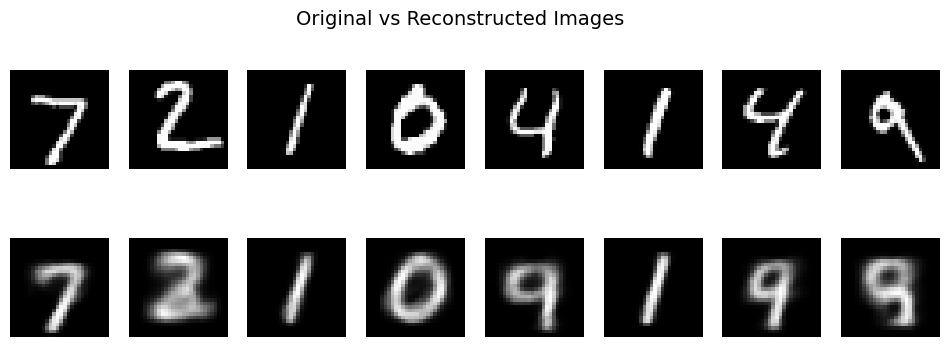

In [76]:
vae.eval()

# Take one batch from the test set
x_test, y_test = next(iter(test_loader))
x_test = x_test.to(device)

with torch.no_grad():
    x_recon, mu, log_var = vae(x_test)

# Move to CPU and reshape
x_test_cpu = x_test.cpu()
x_recon_cpu = x_recon.cpu().view(-1, 1, 28, 28)

num_images = 8
fig, axes = plt.subplots(2, num_images, figsize=(12, 4))

for i in range(num_images):
    # Original
    axes[0, i].imshow(x_test_cpu[i].squeeze(0), cmap="gray")
    axes[0, i].axis("off")
    if i == 0:
        axes[0, i].set_ylabel("Original", fontsize=12)

    # Reconstruction
    axes[1, i].imshow(x_recon_cpu[i].squeeze(0), cmap="gray")
    axes[1, i].axis("off")
    if i == 0:
        axes[1, i].set_ylabel("Reconstructed", fontsize=12)

plt.suptitle("Original vs Reconstructed Images", fontsize=14)
plt.show()

## 14. Sampling from the Latent Space

One of the fun parts of a VAE is that we can:

- Sample random points `z` from the prior distribution (here, N(0, I))
- Decode those points to generate new images

Since our latent dimension is 2, we can also explore a grid of points in the 2D latent space.

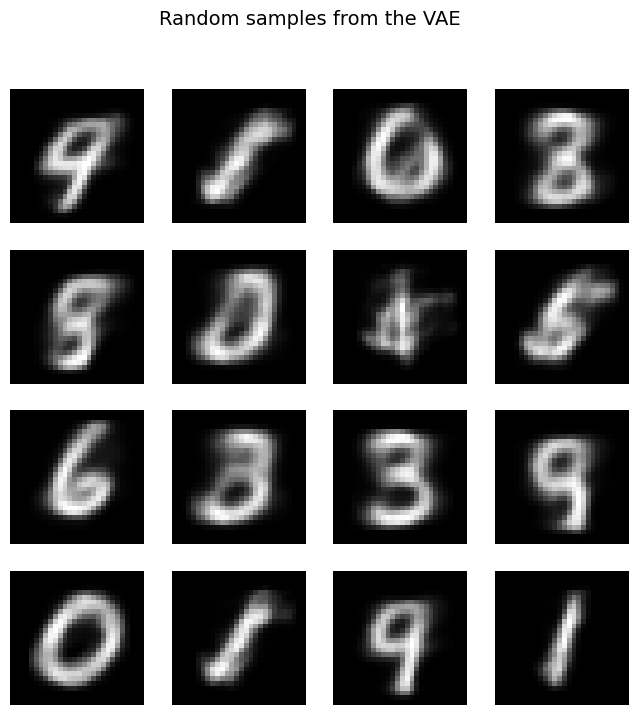

In [77]:
def sample_random_images(model, num_samples: int = 16):
    model.eval()
    with torch.no_grad():
        # Sample z from standard normal
        z = torch.randn(num_samples, latent_dim).to(device)
        # Decode to get images
        samples = model.decoder(z)
        samples = samples.view(-1, 1, 28, 28).cpu()

    # Plot the sampled images
    num_cols = 4
    num_rows = int(np.ceil(num_samples / num_cols))

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(8, 8))
    axes = axes.flatten()

    for i in range(num_samples):
        axes[i].imshow(samples[i].squeeze(0), cmap="gray")
        axes[i].axis("off")

    for i in range(num_samples, len(axes)):
        axes[i].axis("off")

    plt.suptitle("Random samples from the VAE", fontsize=14)
    plt.show()


sample_random_images(vae, num_samples=16)

## 15. Visualizing the Latent Space (Optional)

Because the latent dimension is 2, we can visualize where different digits live in latent space.

Steps:

- Encode many test images to get their μ vectors (we use μ as a point estimate of z)
- Plot the μ's in 2D
- Color points by their digit label

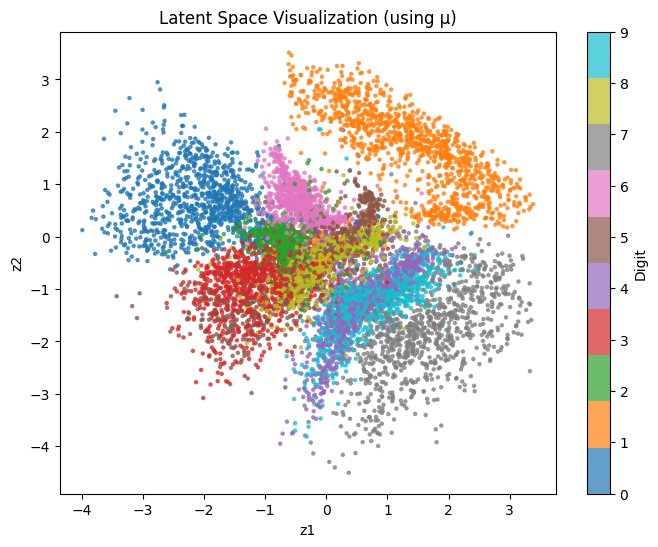

In [ ]:
def plot_latent_space(model, data_loader, device, num_batches: int = 100):
    model.eval()
    zs = []
    ys = []

    with torch.no_grad():
        for i, (x, y) in enumerate(data_loader):
            if i >= num_batches:
                break
            x = x.to(device)
            # Pass through encoder only
            x_flat = x.view(x.size(0), -1)
            mu, log_var = model.encoder(x_flat)
            zs.append(mu.cpu().numpy())
            ys.append(y.numpy())

    zs = np.concatenate(zs, axis=0)
    ys = np.concatenate(ys, axis=0)

    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(zs[:, 0], zs[:, 1], c=ys, cmap="tab10", s=5, alpha=0.7)
    plt.colorbar(scatter, ticks=range(10), label="Digit")
    plt.xlabel("z1")
    plt.ylabel("z2")
    plt.title("Latent Space Visualization (using μ)")
    plt.show()


plot_latent_space(vae, test_loader, device, num_batches=200)

## Summary

In this notebook, we:

- Loaded and visualized the MNIST dataset.
- Built the pieces of a Variational Autoencoder:
  - Encoder producing `mu` and `log_var`.
  - Reparameterization function for sampling latent codes.
  - Decoder mapping latent codes back to images.
- Defined the VAE loss combining reconstruction error and KL divergence.
- Trained the VAE and monitored training and test losses.
- Visualized reconstructions and samples from the latent space.
- (Optionally) visualized the 2D latent space with digit labels.

This implementation is intentionally simple and uses fully connected layers.
One can extend it by:

- Using convolutional layers for better image quality.
- Increasing the latent dimension.
- Training for more epochs or with different optimizers.